# Event Weight Diagnostics and Generation-Level Effective Area

This notebook inspects LeptonInjector and LeptonWeighter event weights stored in CSV files.

The main object is `oneweight`, computed upstream with `weighter.get_oneweight(event)`. This quantity is flux independent. It removes the Monte Carlo generation bias and also contains interaction, cross-section, column-depth, and injection-geometry information. Therefore, its energy scaling is not expected to be only the inverse of the generated spectrum.

Interpretation used throughout this notebook:

- **Unweighted plots** check the Monte Carlo generation phase space.
- **LIW-weighted plots** show the expected generation-level interaction contribution under a flat incident flux convention.
- **Astrophysical flux-weighted plots** are made later by multiplying `oneweight` by an external flux shape, for example `E^-3`.
- **Effective area plots are generation-level / interaction-level only**, because this dataset is before PMT response, trigger, reconstruction, and analysis cuts.

Each section first states what we expect. After the code cell, a short interpretation explains whether the plot should be considered healthy and how to read it.


## 1. Imports, configuration, and helper functions

All imports are kept in this first code cell. The rest of the notebook reuses these imports and helper functions.

In [1]:
from pathlib import Path

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# User configuration
DATA_DIR = Path("/project/def-nahee/kbas/Graphnet-Applications/Metadata/EventWeights/String340MC")
CSV_PATTERN = "*.csv"

# Generated spectral index used by LeptonInjector.
# If PowerLawIndex = 1.5, the generation spectrum is approximately dN/dE ~ E^-1.5.
GENERATED_POWER_INDEX = 1.5

# Optional astrophysical flux shape for later checks: Phi(E) ~ E^-gamma.
ASTRO_GAMMA = 3.0

# Plot defaults
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# Helper functions
def load_event_weight_csvs(data_dir: Path, pattern: str = "*.csv") -> pd.DataFrame:
    """Load all CSV files in a directory and concatenate them into one DataFrame."""
    files = sorted(data_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {data_dir} with pattern {pattern!r}")

    frames = []
    empty_files = []
    for file in files:
        df_file = pd.read_csv(file)
        if len(df_file) == 0:
            empty_files.append(file.name)
        else:
            frames.append(df_file)

    if not frames:
        raise ValueError(f"All CSV files are empty in {data_dir}")

    df_loaded = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(files)} CSV files")
    print(f"Non-empty files: {len(frames)}")
    print(f"Empty files: {len(empty_files)}")
    print(f"Total rows: {len(df_loaded):,}")
    if empty_files:
        print("Example empty files:", empty_files[:10])

    return df_loaded


def clean_event_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Keep rows with finite positive energy and oneweight, and finite zenith."""
    required = ["energy", "oneweight", "zenith"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    valid = (
        np.isfinite(df["energy"]) &
        np.isfinite(df["oneweight"]) &
        np.isfinite(df["zenith"]) &
        (df["energy"] > 0) &
        (df["oneweight"] > 0)
    )

    cleaned = df.loc[valid].copy()
    cleaned["cos_zenith"] = np.cos(cleaned["zenith"].values)

    for column in ["columnDepth", "totalColumnDepth", "azimuth"]:
        if column in cleaned.columns:
            cleaned[column] = pd.to_numeric(cleaned[column], errors="coerce")

    print(f"Rows before cleaning: {len(df):,}")
    print(f"Rows after cleaning:  {len(cleaned):,}")
    return cleaned


def log_bin_centers(edges: np.ndarray) -> np.ndarray:
    """Return geometric bin centers for log-spaced bins."""
    return np.sqrt(edges[:-1] * edges[1:])


def binned_median_fit(x: np.ndarray, y: np.ndarray, bins: np.ndarray, min_count: int = 20):
    """Fit log10(y) vs log10(x) using medians inside log10(x) bins."""
    logx = np.log10(x)
    logy = np.log10(y)
    bin_id = np.digitize(logx, bins)

    x_med = []
    y_med = []
    counts = []

    for i in range(1, len(bins)):
        mask = bin_id == i
        if mask.sum() >= min_count:
            x_med.append(np.median(logx[mask]))
            y_med.append(np.median(logy[mask]))
            counts.append(mask.sum())

    x_med = np.array(x_med)
    y_med = np.array(y_med)
    counts = np.array(counts)

    if len(x_med) < 2:
        raise ValueError("Not enough populated bins for a median fit")

    slope, intercept = np.polyfit(x_med, y_med, 1)
    return slope, intercept, x_med, y_med, counts


def fit_power_law(x: np.ndarray, y: np.ndarray):
    """Fit y ~ x^slope using positive finite values."""
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if mask.sum() < 2:
        raise ValueError("Not enough positive finite points for power-law fit")
    slope, intercept = np.polyfit(np.log10(x[mask]), np.log10(y[mask]), 1)
    return slope, intercept, mask


def weighted_histogram(x: np.ndarray, bins: np.ndarray, weights: np.ndarray | None = None):
    """Return histogram and bin centers."""
    hist, edges = np.histogram(x, bins=bins, weights=weights)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return hist, centers, edges


def weighted_sum_and_uncertainty(x: np.ndarray, bins: np.ndarray, weights: np.ndarray):
    """Return sum of weights and the standard MC statistical uncertainty per bin."""
    sum_w, edges = np.histogram(x, bins=bins, weights=weights)
    sum_w2, _ = np.histogram(x, bins=bins, weights=weights**2)
    sigma_sum_w = np.sqrt(sum_w2)
    centers = log_bin_centers(edges)
    return sum_w, sigma_sum_w, centers, edges


def safe_log_step(x: np.ndarray, y: np.ndarray, *, label: str | None = None, linewidth: float = 2):
    """Draw a step plot only for positive y values, useful for log-scale plots."""
    mask = np.isfinite(x) & np.isfinite(y) & (y > 0)
    plt.step(x[mask], y[mask], where="mid", label=label, linewidth=linewidth)


**Interpretation.** If unique IDs are much lower than the total row count, check whether files were merged multiple times or whether the ID definition is not unique across runs. If the counts look consistent, the table is suitable for the following diagnostics.


## 2. Load the event-weight CSV files

**Expectation.** The notebook should find the partial CSV files produced by the LIW pipeline and concatenate the non-empty ones. Empty files can happen for failed or empty batches and are reported separately.


In [ ]:
df_raw = load_event_weight_csvs(DATA_DIR, CSV_PATTERN)
df_raw.head()

# the name of the 4 csv's are: Electron_LIW, Tau_LIW, Muon_LIW, NC_LIW

Loaded 4 CSV files
Non-empty files: 4
Empty files: 0
Total rows: 7,295,729


,RunID,SubrunID,EventID,SubEventID,energy,zenith,azimuth,finalStateX,finalStateY,columnDepth,initialType,finalType1,finalType2,oneweight,LIW
0,16,4294967295,1,0,5602.156131,2.036595,6.078273,0.031648,0.226093,1.429114e+06,12,11,-2000001006,9.990426e+09,1.459948e+06
1,16,4294967295,2,0,629.257089,0.963156,5.654796,0.032920,0.516285,4.579691e+05,12,11,-2000001006,1.653031e+07,2.415653e+03
2,16,4294967295,3,0,812.299139,1.390196,0.913883,0.141857,0.429699,5.414886e+05,12,11,-2000001006,3.662173e+07,5.351707e+03
3,16,4294967295,4,0,4708.643112,2.102868,5.345124,0.079075,0.478249,1.119700e+06,12,11,-2000001006,5.215321e+09,7.621395e+05
4,16,4294967295,5,0,401.972052,2.082871,0.936296,0.195497,0.651164,6.976245e+05,12,11,-2000001006,8.325470e+06,1.216640e+03


**Interpretation.** A healthy load should report many non-empty files and a positive total row count. If many expected files are missing, the merged sample is incomplete and weighted sums can be biased.


## 3. Basic bookkeeping checks

**Expectation.** Event identifiers should look sensible after merging. The total number of rows should be compatible with the number of generated events that survived the file matching and cleaning steps.


In [3]:
for column in ["RunID", "SubrunID", "EventID", "SubEventID"]:
    if column in df_raw.columns:
        print(f"{column}: {df_raw[column].nunique():,} unique values")
    else:
        print(f"{column}: missing")

print(f"Total rows: {len(df_raw):,}")

RunID: 10,000 unique values
SubrunID: 1 unique values
EventID: 200 unique values
SubEventID: 1 unique values
Total rows: 7,295,729


## 4. Clean the DataFrame

**Expectation.** The cleaning step should remove non-finite or non-positive `energy` and `oneweight` values. The number of removed rows should be small unless there were corrupt or incomplete files.


In [4]:
df = clean_event_dataframe(df_raw)

E = df["energy"].to_numpy()
W = df["oneweight"].to_numpy()
zenith = df["zenith"].to_numpy()
cosz = df["cos_zenith"].to_numpy()

print(df[["energy", "oneweight", "zenith", "cos_zenith"]].describe())

Rows before cleaning: 7,295,729
Rows after cleaning:  7,295,729
             energy     oneweight        zenith    cos_zenith
count  7.295729e+06  7.295729e+06  7.295729e+06  7.295729e+06
mean   1.557300e+04  2.945399e+13  1.571037e+00 -2.069668e-04
std    1.719309e+05  1.344414e+15  6.836244e-01  5.773516e-01
min    1.000000e+02  1.824553e+04  7.124400e-04 -1.000000e+00
25%    1.768745e+02  4.296132e+05  1.047361e+00 -5.001344e-01
50%    3.935090e+02  3.844844e+06  1.571218e+00 -4.218142e-04
75%    1.523257e+03  1.556259e+08  2.094550e+00  4.998581e-01
max    9.999659e+06  1.721150e+17  3.141349e+00  9.999997e-01


## 5. Main generation and LIW sanity checks

**Expectation.** The generated directions should be approximately uniform in `cos(zenith)`. The unweighted energy histogram in log-spaced bins should have slope close to `-0.5` if the true generated spectrum is `dN/dE ∝ E^-1.5`, because log-bin widths grow approximately as `E`. The LIW median slope is not expected to be exactly `+1.5`, because `oneweight` is not only inverse generation. It also contains interaction, cross-section, column-depth, and geometry effects.


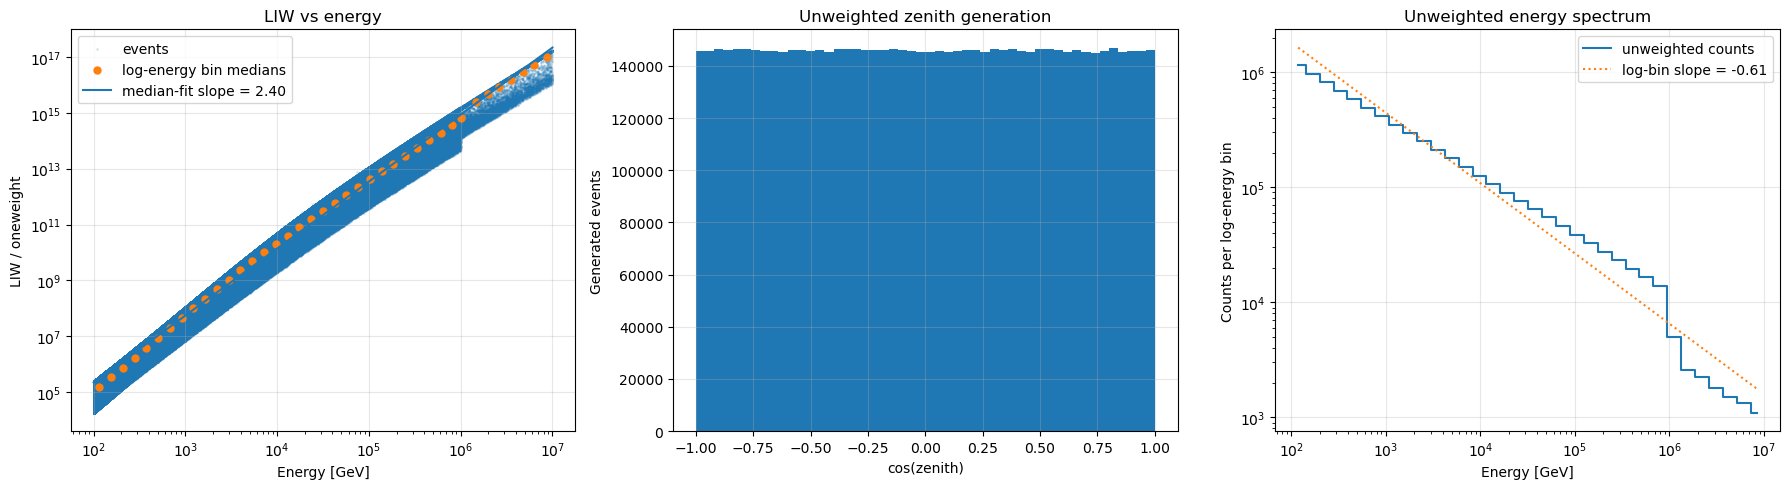

LIW vs energy binned-median slope: 2.397
Energy histogram log-bin slope:    -0.611

Interpretation:
- LIW is not expected to scale only as E^{+1.5}; it also contains interaction/cross-section effects.
- If dN/dE ~ E^{-1.5}, then counts in log-spaced bins look roughly like E^{-0.5}.


In [5]:
logE = np.log10(E)
logW = np.log10(W)

# LIW vs energy: fit binned medians in log-energy bins.
median_bins = np.linspace(logE.min(), logE.max(), 40)
liw_slope, liw_intercept, x_med, y_med, median_counts = binned_median_fit(
    E, W, median_bins, min_count=20
)

energy_range = np.logspace(logE.min(), logE.max(), 200)
liw_fit = 10**liw_intercept * energy_range**liw_slope

# Counts per log-energy bin.
energy_bins = np.logspace(logE.min(), logE.max(), 35)
counts, energy_edges = np.histogram(E, bins=energy_bins)
energy_centers = log_bin_centers(energy_edges)

energy_slope_logbin, energy_intercept_logbin, nonzero_logbin = fit_power_law(
    energy_centers, counts
)
energy_fit_logbin = 10**energy_intercept_logbin * energy_centers**energy_slope_logbin

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. LIW vs energy.
axes[0].scatter(E, W, alpha=0.15, s=1, label="events")
axes[0].scatter(10**x_med, 10**y_med, s=25, label="log-energy bin medians")
axes[0].plot(energy_range, liw_fit, label=f"median-fit slope = {liw_slope:.2f}")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Energy [GeV]")
axes[0].set_ylabel("LIW / oneweight")
axes[0].set_title("LIW vs energy")
axes[0].legend()

# 2. Unweighted zenith generation.
axes[1].hist(cosz, bins=50)
axes[1].set_xlabel("cos(zenith)")
axes[1].set_ylabel("Generated events")
axes[1].set_title("Unweighted zenith generation")

# 3. Counts per log-energy bin.
axes[2].step(energy_centers, counts, where="mid", label="unweighted counts")
axes[2].plot(energy_centers[nonzero_logbin], energy_fit_logbin[nonzero_logbin],
             linestyle=":", label=f"log-bin slope = {energy_slope_logbin:.2f}")
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel("Energy [GeV]")
axes[2].set_ylabel("Counts per log-energy bin")
axes[2].set_title("Unweighted energy spectrum")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"LIW vs energy binned-median slope: {liw_slope:.3f}")
print(f"Energy histogram log-bin slope:    {energy_slope_logbin:.3f}")
print()
print("Interpretation:")
print("- LIW is not expected to scale only as E^{+1.5}; it also contains interaction/cross-section effects.")
print("- If dN/dE ~ E^{-1.5}, then counts in log-spaced bins look roughly like E^{-0.5}.")

**Interpretation.** A flat unweighted `cos(zenith)` histogram confirms that directions were generated uniformly in solid angle. A log-bin energy slope near `-0.5` is consistent with a generated `dN/dE` slope near `-1.5`. If the LIW slope remains steeper than `+1.5`, that is expected and indicates that LIW carries physical interaction information in addition to the inverse generation spectrum.


## 6. Direct generated `dN/dE` estimate

**Expectation.** This section divides the energy-bin counts by the linear bin width `ΔE`. Unlike counts per log-energy bin, this estimates `dN/dE` directly. For `PowerLawIndex = 1.5`, the fitted slope should be close to `-1.5` within Monte Carlo statistics.


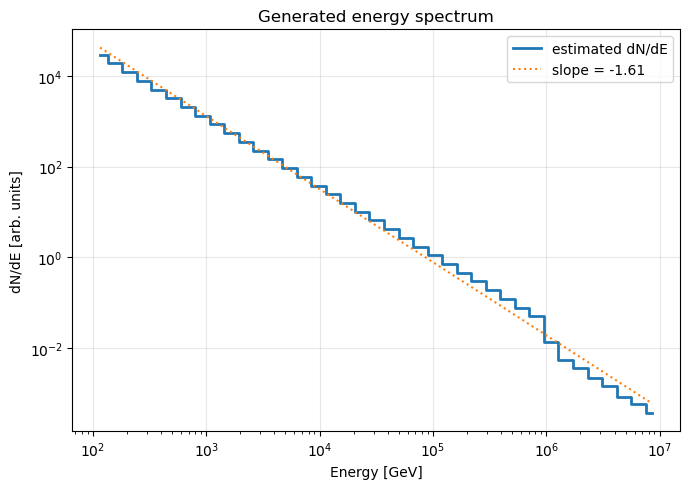

Measured generated dN/dE slope: -1.612
Expected approximate slope:     -1.500


In [6]:
dnde_bins = np.logspace(logE.min(), logE.max(), 40)
dnde_counts, dnde_edges = np.histogram(E, bins=dnde_bins)
dnde_centers = log_bin_centers(dnde_edges)
dnde_widths = np.diff(dnde_edges)
dnde = dnde_counts / dnde_widths

dnde_slope, dnde_intercept, dnde_mask = fit_power_law(dnde_centers, dnde)
dnde_fit = 10**dnde_intercept * dnde_centers**dnde_slope

plt.figure()
safe_log_step(dnde_centers, dnde, label="estimated dN/dE")
plt.plot(dnde_centers[dnde_mask], dnde_fit[dnde_mask], linestyle=":",
         label=f"slope = {dnde_slope:.2f}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel("dN/dE [arb. units]")
plt.title("Generated energy spectrum")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Measured generated dN/dE slope: {dnde_slope:.3f}")
print(f"Expected approximate slope:     {-GENERATED_POWER_INDEX:.3f}")

**Interpretation.** If this slope is close to `-1.5`, the generated energy spectrum is behaving as configured. This is the correct plot to use when checking the actual generation spectral index. The log-bin count plot checks a different quantity and is expected to show a slope shifted by `+1`.


## 7. LIW distribution

**Expectation.** The raw `oneweight` values usually span many orders of magnitude. A long high-weight tail is common because rare high-energy or high-contribution events can represent a large physical phase-space contribution.


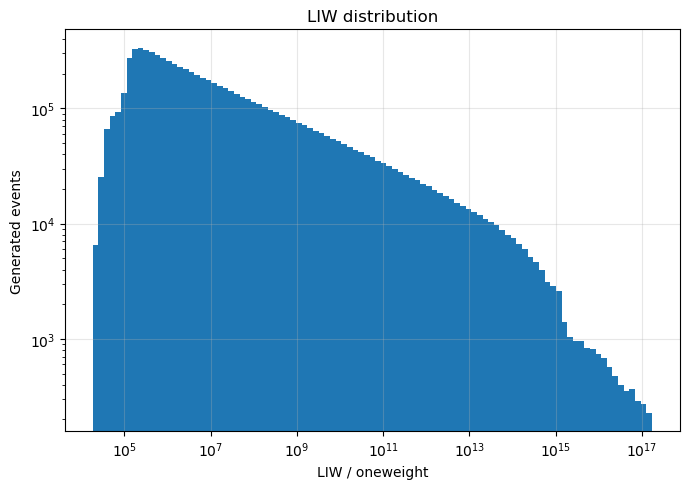

min:    1.824553e+04
median: 3.844844e+06
max:    1.721150e+17


In [7]:
weight_bins = np.logspace(np.log10(W.min()), np.log10(W.max()), 100)

plt.figure()
plt.hist(W, bins=weight_bins)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("LIW / oneweight")
plt.ylabel("Generated events")
plt.title("LIW distribution")
plt.tight_layout()
plt.show()

print(f"min:    {W.min():.6e}")
print(f"median: {np.median(W):.6e}")
print(f"max:    {W.max():.6e}")

**Interpretation.** A broad distribution is not automatically a problem. It means weighted sums should be interpreted together with outlier diagnostics, because a small number of events can dominate the total weight in a bin.


## 8. Check whether LIW is only inverse generation

**Expectation.** Dividing `oneweight` by `E^1.5` removes the dominant inverse-generation trend expected from an `E^-1.5` generation spectrum. If LIW were only inverse generation, this ratio would be approximately flat. We expect it not to be flat, because LIW also contains interaction and propagation information.


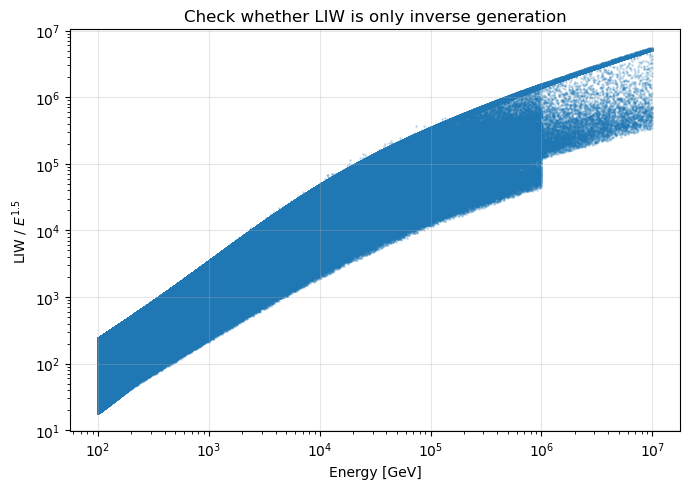

In [8]:
plt.figure()
plt.scatter(E, W / E**GENERATED_POWER_INDEX, s=1, alpha=0.2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel(rf"LIW / $E^{{{GENERATED_POWER_INDEX}}}$")
plt.title("Check whether LIW is only inverse generation")
plt.tight_layout()
plt.show()

**Interpretation.** If the ratio still increases with energy, LIW is not just undoing the generation spectrum. The remaining energy dependence is the physical part, mainly cross-section and interaction probability effects, with additional geometry and column-depth dependence.


## 9. Column depth versus local zenith

**Expectation.** `totalColumnDepth` is the material column associated with the event direction and interaction setup. It is not only the distance inside the detector volume. Since the Earth path and overburden change with zenith, `columnDepth` is expected to depend on `cos(zenith)`. A sharp lower envelope can be physical because every event must pass through at least a minimum amount of material before reaching the interaction region.


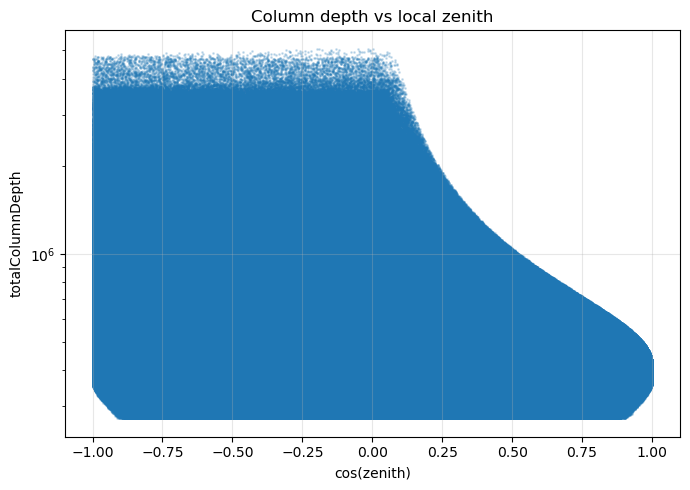

In [9]:
column_depth_column = None
for candidate in ["columnDepth", "totalColumnDepth"]:
    if candidate in df.columns:
        column_depth_column = candidate
        break

if column_depth_column is None:
    print("No column-depth column is available in this DataFrame.")
else:
    column_depth_all = df[column_depth_column].to_numpy()
    valid_column_depth = np.isfinite(column_depth_all) & (column_depth_all > 0)

    plt.figure()
    plt.scatter(cosz[valid_column_depth], column_depth_all[valid_column_depth], s=1, alpha=0.2)
    plt.yscale("log")
    plt.xlabel("cos(zenith)")
    plt.ylabel("totalColumnDepth")
    plt.title("Column depth vs local zenith")
    plt.tight_layout()
    plt.show()


**Interpretation.** The broad cloud means that the same local zenith can still correspond to different interaction positions, impact parameters, and injection-geometry configurations. The lower edge is expected to be nonzero because even the shortest paths still pass through a minimum material column before reaching the interaction region.


## 10. Column depth by azimuth band

**Expectation.** If azimuth is the main reason for the broad column-depth cloud, the shape should change strongly between azimuth bands. If the shapes are similar, the dominant effect is more likely local zenith, vertex position, injection geometry, and minimum overburden rather than azimuth alone.


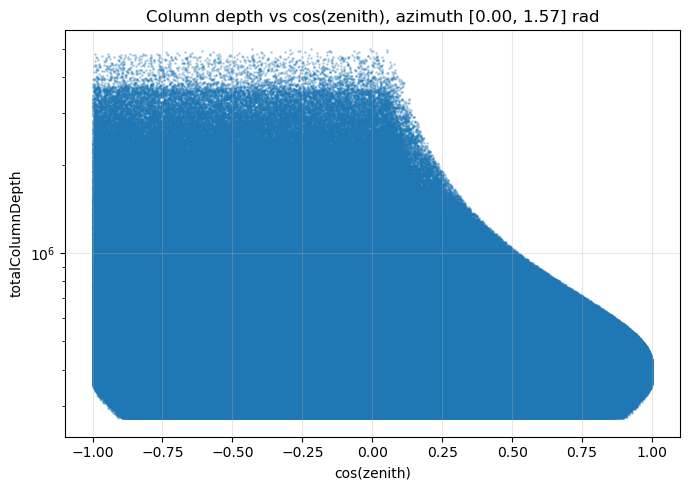

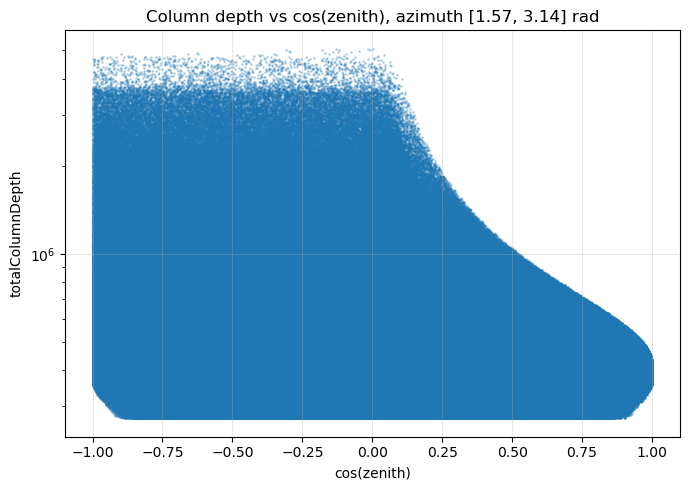

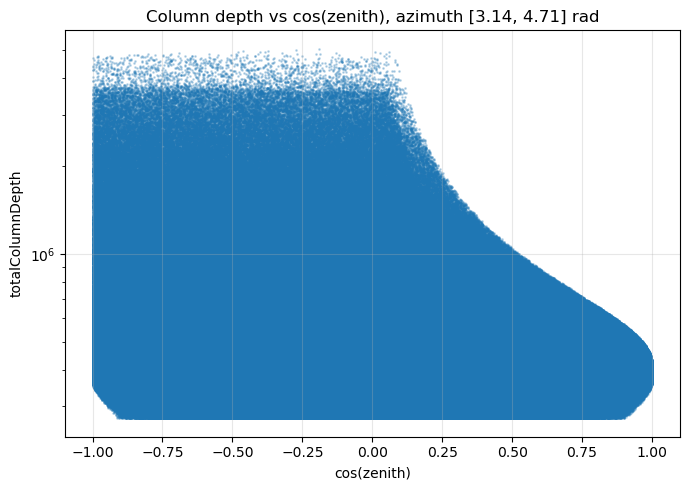

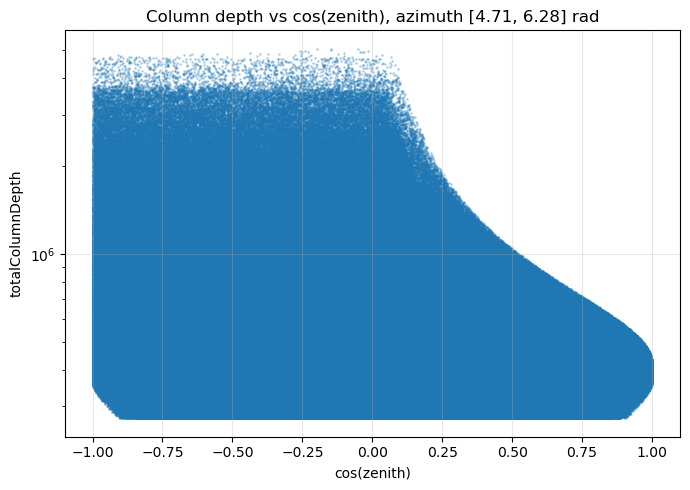

In [10]:
if column_depth_column is None or "azimuth" not in df.columns:
    print("Column-depth or azimuth information is not available.")
else:
    cosz_cd = df["cos_zenith"].to_numpy()
    az_cd = df["azimuth"].to_numpy()
    column_depth_cd = df[column_depth_column].to_numpy()

    valid_cd = (
        np.isfinite(cosz_cd) &
        np.isfinite(az_cd) &
        np.isfinite(column_depth_cd) &
        (column_depth_cd > 0)
    )

    cosz_cd = cosz_cd[valid_cd]
    az_cd = az_cd[valid_cd]
    column_depth_cd = column_depth_cd[valid_cd]

    azimuth_bands = [
        (0, np.pi / 2),
        (np.pi / 2, np.pi),
        (np.pi, 3 * np.pi / 2),
        (3 * np.pi / 2, 2 * np.pi),
    ]

    for az_min, az_max in azimuth_bands:
        mask = (az_cd >= az_min) & (az_cd < az_max)

        plt.figure(figsize=(7, 5))
        plt.scatter(cosz_cd[mask], column_depth_cd[mask], s=1, alpha=0.25)
        plt.yscale("log")
        plt.xlabel("cos(zenith)")
        plt.ylabel("totalColumnDepth")
        plt.title(f"Column depth vs cos(zenith), azimuth [{az_min:.2f}, {az_max:.2f}] rad")
        plt.tight_layout()
        plt.show()


**Interpretation.** If all azimuth bands show the same overall footprint, the broad shape is not an azimuth artifact. Small differences between bands are normal, but the main structure should be interpreted as a combination of local zenith, event position, injection geometry, and Earth or medium column depth.


## 11. Column-depth percentile bands and lower envelope

**Expectation.** The median and percentile bands should summarize the broad scatter cloud. The lower envelope should not be interpreted as suspicious just because it is sharp. It can represent the minimum material column required for events to reach the interaction region. A real physical lower envelope should have nearby values that vary smoothly, not many identical repeated values.


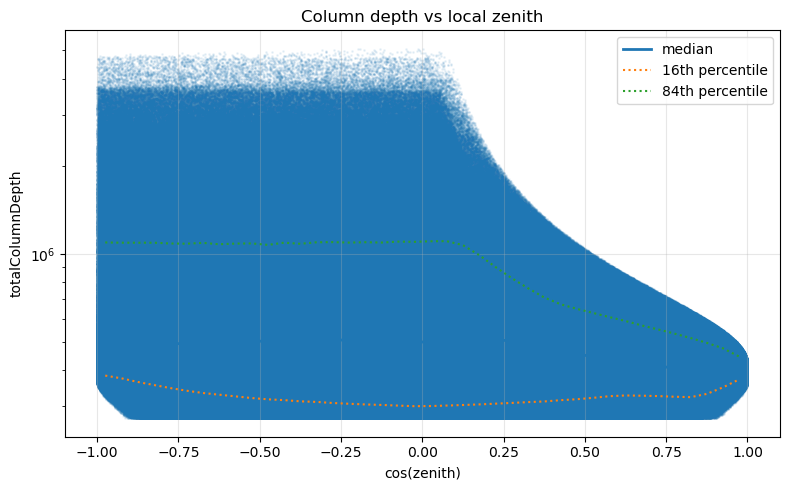

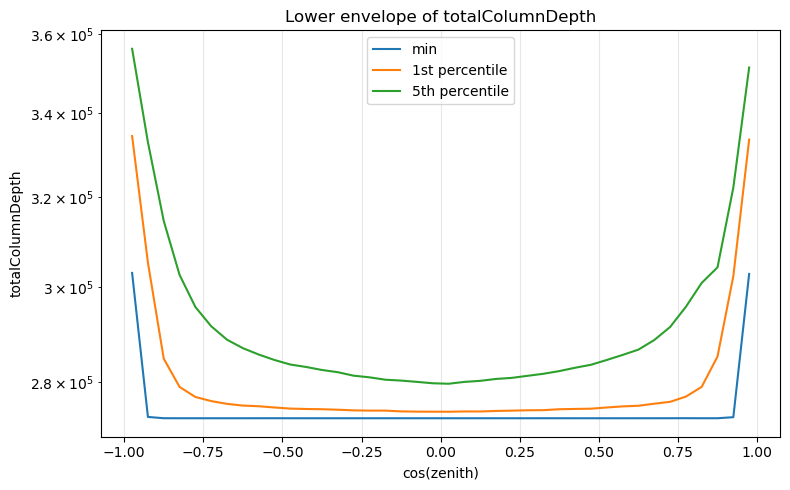

min:    272836.066426
1%:     275102.678507
5%:     285425.672003
median: 456418.141279
Smallest 20 values:
[272836.06642594 272836.12883971 272836.19745999 272836.27333676
 272836.30908196 272836.34412722 272836.34601715 272836.36013326
 272836.42196423 272836.43405044 272836.54497317 272836.56300891
 272836.63989006 272836.64623653 272836.70720468 272836.71844359
 272836.78836122 272836.83016792 272836.83201282 272836.89288633]


In [11]:
if column_depth_column is None:
    print("No column-depth column is available in this DataFrame.")
else:
    cosz_cd = df["cos_zenith"].to_numpy()
    column_depth_cd = df[column_depth_column].to_numpy()
    valid_cd = np.isfinite(cosz_cd) & np.isfinite(column_depth_cd) & (column_depth_cd > 0)
    cosz_cd = cosz_cd[valid_cd]
    column_depth_cd = column_depth_cd[valid_cd]

    column_bins = np.linspace(-1, 1, 41)
    column_centers = 0.5 * (column_bins[:-1] + column_bins[1:])

    median_cd = []
    p16_cd = []
    p84_cd = []
    min_cd = []
    p01_cd = []
    p05_cd = []

    for lo, hi in zip(column_bins[:-1], column_bins[1:]):
        mask = (cosz_cd >= lo) & (cosz_cd < hi)
        if mask.sum() > 0:
            values = column_depth_cd[mask]
            median_cd.append(np.median(values))
            p16_cd.append(np.percentile(values, 16))
            p84_cd.append(np.percentile(values, 84))
            min_cd.append(np.min(values))
            p01_cd.append(np.percentile(values, 1))
            p05_cd.append(np.percentile(values, 5))
        else:
            median_cd.append(np.nan)
            p16_cd.append(np.nan)
            p84_cd.append(np.nan)
            min_cd.append(np.nan)
            p01_cd.append(np.nan)
            p05_cd.append(np.nan)

    plt.figure(figsize=(8, 5))
    plt.scatter(cosz_cd, column_depth_cd, s=1, alpha=0.08)
    plt.plot(column_centers, median_cd, linewidth=2, label="median")
    plt.plot(column_centers, p16_cd, linestyle=":", label="16th percentile")
    plt.plot(column_centers, p84_cd, linestyle=":", label="84th percentile")
    plt.yscale("log")
    plt.xlabel("cos(zenith)")
    plt.ylabel("totalColumnDepth")
    plt.title("Column depth vs local zenith")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(column_centers, min_cd, label="min")
    plt.plot(column_centers, p01_cd, label="1st percentile")
    plt.plot(column_centers, p05_cd, label="5th percentile")
    plt.yscale("log")
    plt.xlabel("cos(zenith)")
    plt.ylabel("totalColumnDepth")
    plt.title("Lower envelope of totalColumnDepth")
    plt.legend()
    plt.tight_layout()
    plt.show()

    smallest_values = np.sort(column_depth_cd[np.isfinite(column_depth_cd)])[:20]
    print(f"min:    {np.nanmin(column_depth_cd):.6f}")
    print(f"1%:     {np.nanpercentile(column_depth_cd, 1):.6f}")
    print(f"5%:     {np.nanpercentile(column_depth_cd, 5):.6f}")
    print(f"median: {np.nanmedian(column_depth_cd):.6f}")
    print("Smallest 20 values:")
    print(smallest_values)


**Interpretation.** If the smallest values are close but not identical, the lower edge is likely a physical or geometrical envelope rather than a hard-coded fill value. A smooth 1st and 5th percentile curve supports the interpretation that the lower boundary comes from minimum overburden and injection geometry.


## 12. LIW-weighted zenith distribution

**Expectation.** The unweighted `cos(zenith)` distribution should be approximately flat if generation was uniform in solid angle. The LIW-weighted distribution does not have to be flat because it is not the incoming neutrino flux. It is the generation-level expected interaction contribution under a flat incident flux convention. Directions with different column depth and geometry can therefore receive different total weights.


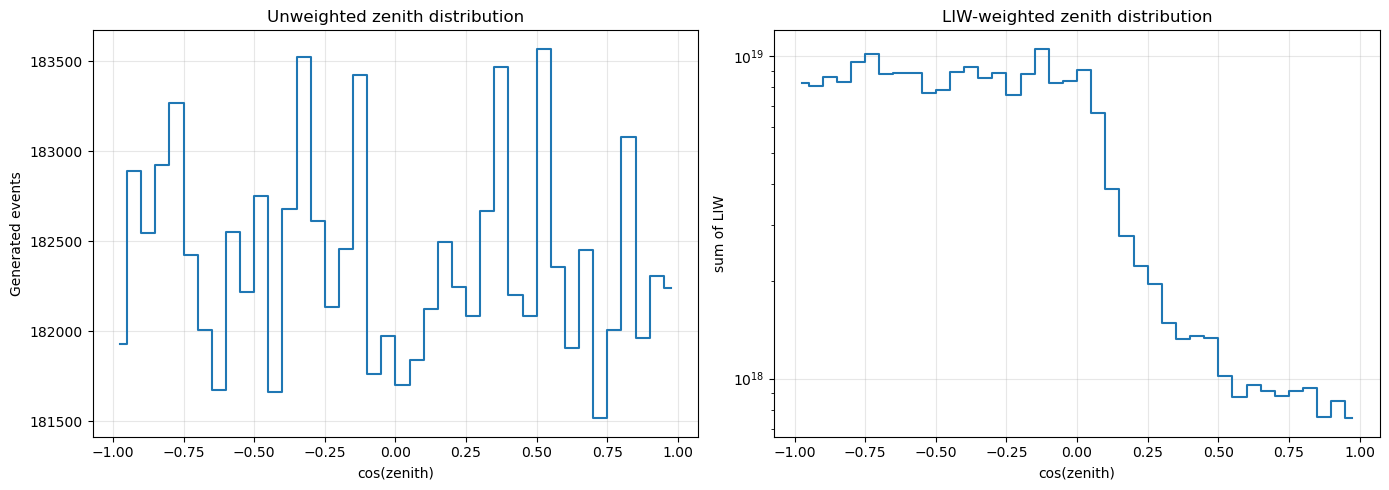

In [12]:
cosz_bins = np.linspace(-1, 1, 41)

unweighted_hist, cosz_centers, _ = weighted_histogram(cosz, cosz_bins)
weighted_hist, _, _ = weighted_histogram(cosz, cosz_bins, weights=W)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].step(cosz_centers, unweighted_hist, where="mid")
axes[0].set_xlabel("cos(zenith)")
axes[0].set_ylabel("Generated events")
axes[0].set_title("Unweighted zenith distribution")

axes[1].step(cosz_centers, weighted_hist, where="mid")
axes[1].set_yscale("log")
axes[1].set_xlabel("cos(zenith)")
axes[1].set_ylabel("sum of LIW")
axes[1].set_title("LIW-weighted zenith distribution")

plt.tight_layout()
plt.show()

**Interpretation.** If the right panel is lower near `cos(zenith) ≈ +1`, that can be normal. This side has smaller column depth in this convention, so the weighted interaction contribution can be smaller even when the incident flux is constant. This plot should not be labeled as the neutrino flux arriving at P-ONE. It is a LIW-weighted interaction contribution plot.


## 13. Per-bin LIW statistics versus zenith

**Expectation.** Weighted sums can be dominated by a few high-weight events. The median should be more stable than the mean or the sum. If the sum changes strongly while the median is smooth, the bin is likely influenced by tails in the weight distribution.


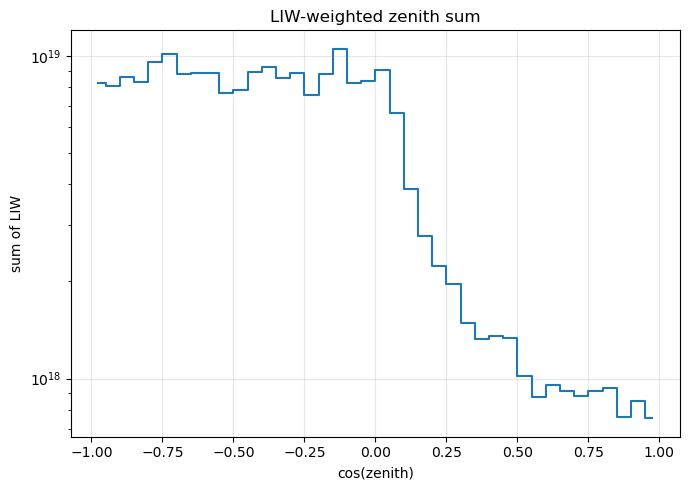

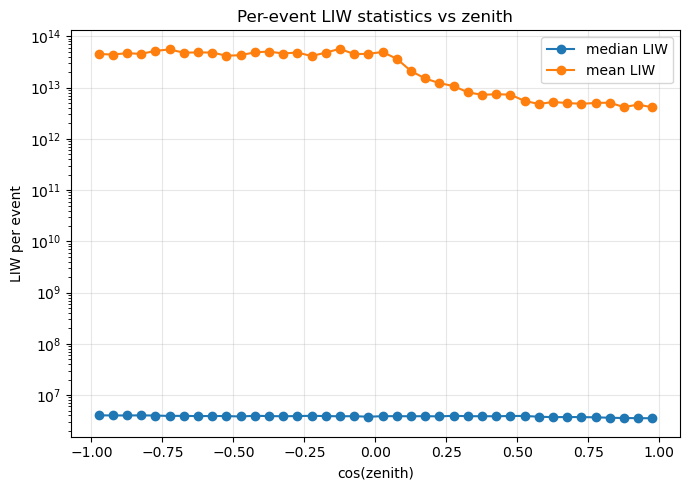

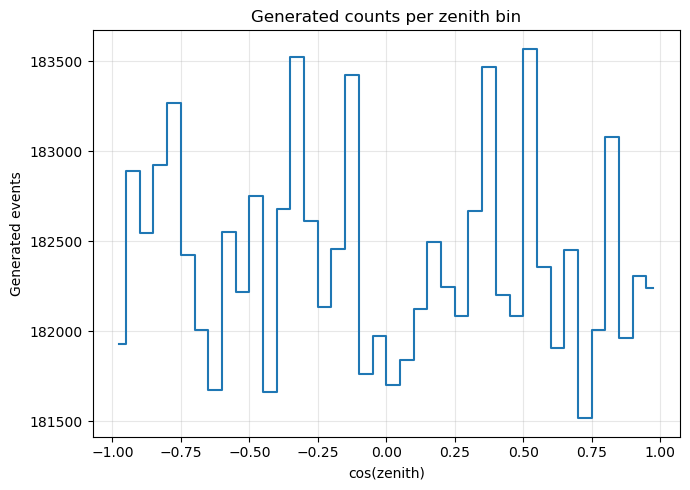

In [13]:
bin_id = np.digitize(cosz, cosz_bins)

x = []
sum_w = []
mean_w = []
median_w = []
counts = []

for i in range(1, len(cosz_bins)):
    mask = bin_id == i
    if mask.sum() == 0:
        continue

    x.append(0.5 * (cosz_bins[i - 1] + cosz_bins[i]))
    sum_w.append(np.sum(W[mask]))
    mean_w.append(np.mean(W[mask]))
    median_w.append(np.median(W[mask]))
    counts.append(mask.sum())

x = np.array(x)
sum_w = np.array(sum_w)
mean_w = np.array(mean_w)
median_w = np.array(median_w)
counts = np.array(counts)

plt.figure()
plt.step(x, sum_w, where="mid")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("sum of LIW")
plt.title("LIW-weighted zenith sum")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x, median_w, marker="o", label="median LIW")
plt.plot(x, mean_w, marker="o", label="mean LIW")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("LIW per event")
plt.title("Per-event LIW statistics vs zenith")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.step(x, counts, where="mid")
plt.xlabel("cos(zenith)")
plt.ylabel("Generated events")
plt.title("Generated counts per zenith bin")
plt.tight_layout()
plt.show()

**Interpretation.** Use the median curve to understand the typical event in each zenith bin. Use the sum curve to understand the total weighted contribution. If the two tell different stories, the total contribution is probably controlled by rare high-weight events.


## 14. Outlier diagnostics for LIW-weighted zenith bins

**Expectation.** If `sum LIW / max LIW` is close to `1`, the bin is dominated by one event. Such bins are statistically unstable and should not be over-interpreted as a smooth physical trend.


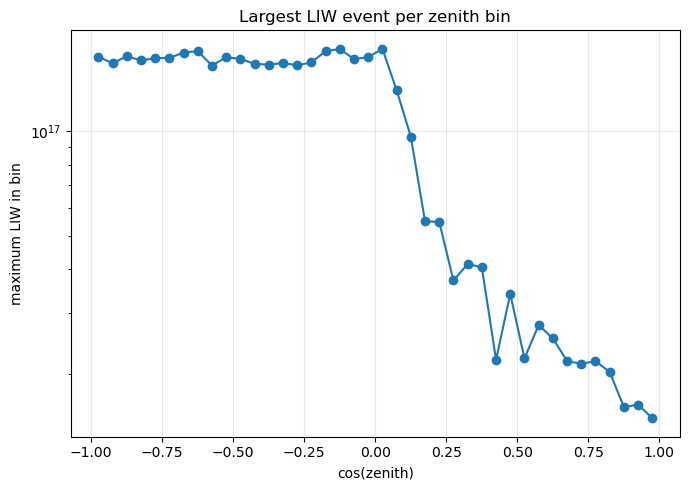

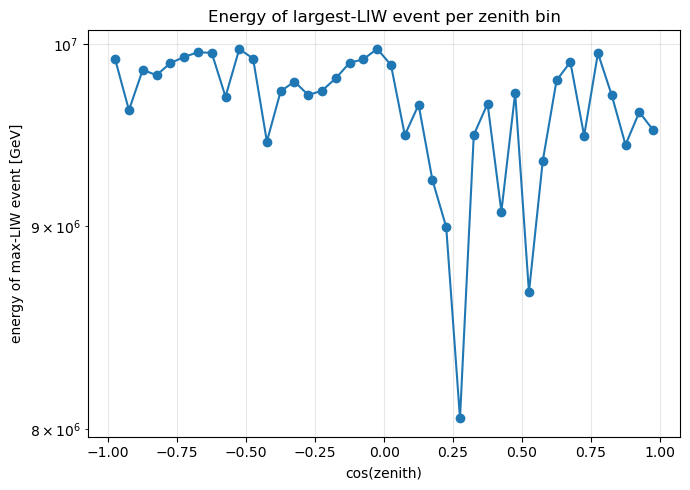

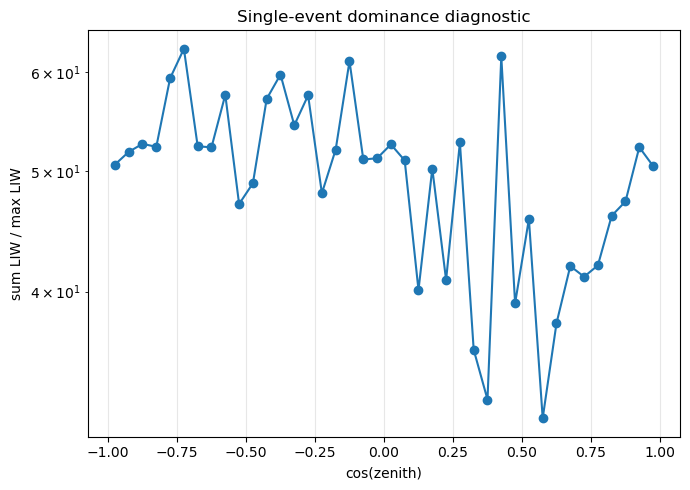

In [14]:
x_out = []
max_w = []
max_E = []
sum_w_out = []

for i in range(1, len(cosz_bins)):
    mask = bin_id == i
    if mask.sum() == 0:
        continue

    local_w = W[mask]
    local_E = E[mask]
    idx = np.argmax(local_w)

    x_out.append(0.5 * (cosz_bins[i - 1] + cosz_bins[i]))
    max_w.append(local_w[idx])
    max_E.append(local_E[idx])
    sum_w_out.append(np.sum(local_w))

x_out = np.array(x_out)
max_w = np.array(max_w)
max_E = np.array(max_E)
sum_w_out = np.array(sum_w_out)

plt.figure()
plt.plot(x_out, max_w, marker="o")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("maximum LIW in bin")
plt.title("Largest LIW event per zenith bin")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x_out, max_E, marker="o")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("energy of max-LIW event [GeV]")
plt.title("Energy of largest-LIW event per zenith bin")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x_out, sum_w_out / max_w, marker="o")
plt.yscale("log")
plt.xlabel("cos(zenith)")
plt.ylabel("sum LIW / max LIW")
plt.title("Single-event dominance diagnostic")
plt.tight_layout()
plt.show()

**Interpretation.** Bins with a small `sum / max` ratio need more Monte Carlo statistics. They can create spikes in weighted histograms and effective-area curves, especially at high energy.


## 15. Apply an astrophysical power-law flux shape

**Expectation.** The LIW pipeline should remain flux-free. To study an astrophysical flux with `Phi(E) ∝ E^-3`, multiply the existing `oneweight` by `E^-3` during analysis. This is a shape-only weighting unless a physical flux normalization and livetime are also included. Since `E^-3` is steep, high-energy events should be suppressed relative to the LIW-only case.


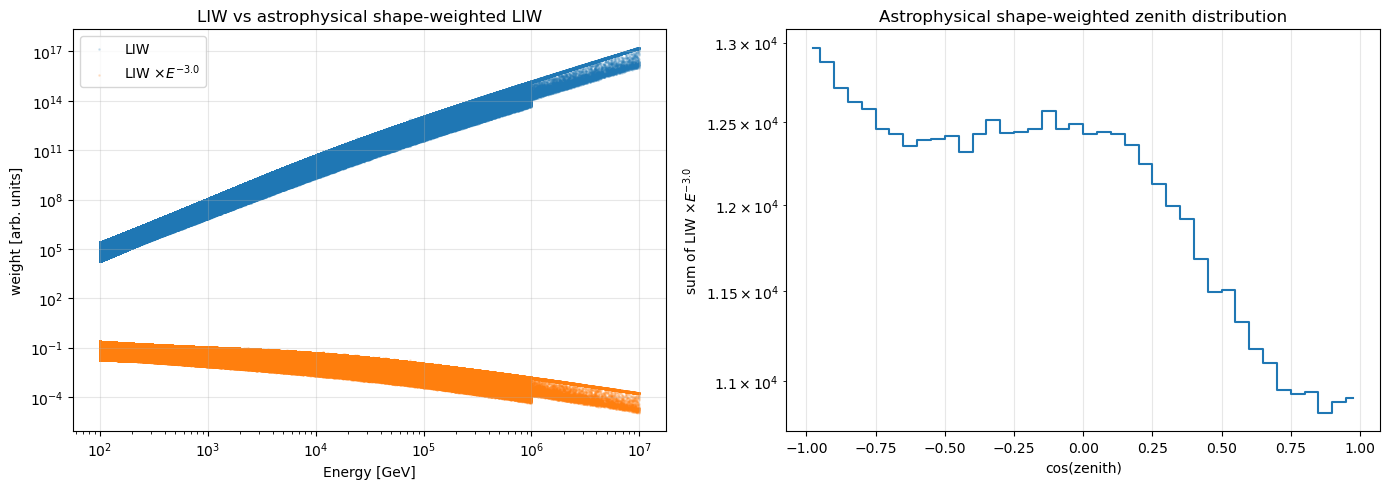

In [15]:
df["astro_weight_shape"] = df["oneweight"] * df["energy"]**(-ASTRO_GAMMA)

astro_W = df["astro_weight_shape"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(E, W, s=1, alpha=0.15, label="LIW")
axes[0].scatter(E, astro_W, s=1, alpha=0.15, label=rf"LIW $\times E^{{-{ASTRO_GAMMA}}}$")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Energy [GeV]")
axes[0].set_ylabel("weight [arb. units]")
axes[0].set_title("LIW vs astrophysical shape-weighted LIW")
axes[0].legend()

astro_hist, _, _ = weighted_histogram(cosz, cosz_bins, weights=astro_W)
axes[1].step(cosz_centers, astro_hist, where="mid")
axes[1].set_yscale("log")
axes[1].set_xlabel("cos(zenith)")
axes[1].set_ylabel(rf"sum of LIW $\times E^{{-{ASTRO_GAMMA}}}$")
axes[1].set_title("Astrophysical shape-weighted zenith distribution")

plt.tight_layout()
plt.show()

**Interpretation.** This plot is no longer an effective area. It is the expected event contribution for a chosen flux shape, up to an overall normalization and livetime. Changing the flux index only requires changing this analysis weight, not recomputing LIW.


## 16. Generation-level all-sky averaged effective area with MC uncertainty

This computes a generation-level all-sky averaged effective area from LIW:

\[
A_{\rm eff}(E) \approx \frac{\sum_{i \in E\;\rm bin} w_i}{\Delta E\,\Delta\Omega}
\]

where `w_i = oneweight_i` and `ΔΩ = 4π` for the all-sky average.

**Expectation.** The curve often increases with energy because the interaction probability and cross-section increase with energy. The shaded band is the Monte Carlo statistical uncertainty estimated as `sqrt(sum(w_i^2)) / (ΔE ΔΩ)`. This is not a final detector-level effective area because PMT response, trigger, reconstruction, and analysis cuts are not applied.


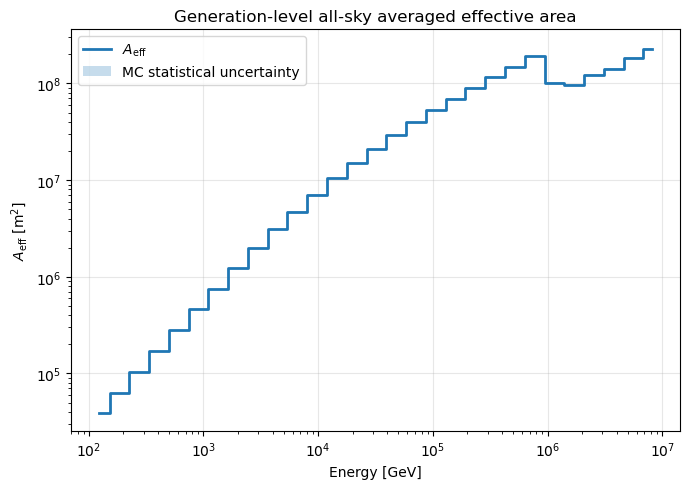

Median relative MC uncertainty: 0.004295639547026481
Maximum relative MC uncertainty: 0.033874945963267775


In [16]:
aeff_bins = np.logspace(logE.min(), logE.max(), 30)
aeff_sum_w, aeff_sigma_sum_w, aeff_centers, aeff_edges = weighted_sum_and_uncertainty(
    E, aeff_bins, W
)
aeff_delta_E = np.diff(aeff_edges)

# Full-sky solid angle.
delta_omega_all_sky = 4 * np.pi

# The oneweight convention here gives area in cm^2 after dividing by dE dOmega.
A_eff_cm2 = aeff_sum_w / (aeff_delta_E * delta_omega_all_sky)
A_eff_unc_cm2 = aeff_sigma_sum_w / (aeff_delta_E * delta_omega_all_sky)

A_eff_m2 = A_eff_cm2 / 1e4
A_eff_unc_m2 = A_eff_unc_cm2 / 1e4

positive = np.isfinite(A_eff_m2) & (A_eff_m2 > 0)
lower = np.maximum(A_eff_m2 - A_eff_unc_m2, np.nextafter(0, 1))
upper = A_eff_m2 + A_eff_unc_m2

plt.figure()
plt.step(aeff_centers[positive], A_eff_m2[positive], where="mid", linewidth=2, label=r"$A_{\rm eff}$")
plt.fill_between(
    aeff_centers[positive],
    lower[positive],
    upper[positive],
    step="mid",
    alpha=0.25,
    label="MC statistical uncertainty",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel(r"$A_{\rm eff}$ [m$^2$]")
plt.title("Generation-level all-sky averaged effective area")
plt.legend()
plt.tight_layout()
plt.show()

relative_unc = np.full_like(A_eff_m2, np.nan, dtype=float)
relative_unc[positive] = A_eff_unc_m2[positive] / A_eff_m2[positive]
print("Median relative MC uncertainty:", np.nanmedian(relative_unc))
print("Maximum relative MC uncertainty:", np.nanmax(relative_unc))


**Interpretation.** A rising curve is expected at generation level. If the uncertainty band grows at high energy, that is usually limited Monte Carlo statistics from the generated `E^-1.5` spectrum. Do not multiply by an astrophysical flux when computing this effective area, because effective area is a detector response quantity.


## 17. Generation-level effective area by local zenith band with MC uncertainty

This separates the effective area by local `cos(zenith)` bands.

Important: this is not true declination binning for P-ONE. The relation `sin(delta) = cos(zenith)` is a special simplification for a detector at the pole. For P-ONE, use detector latitude and event direction to compute true declination if needed.

**Expectation.** High-energy bins can be noisy because the `E^-1.5` generation spectrum leaves fewer events at high energy. Splitting into angular bands further reduces statistics. The uncertainty bars should therefore become larger in sparsely populated high-energy bins.


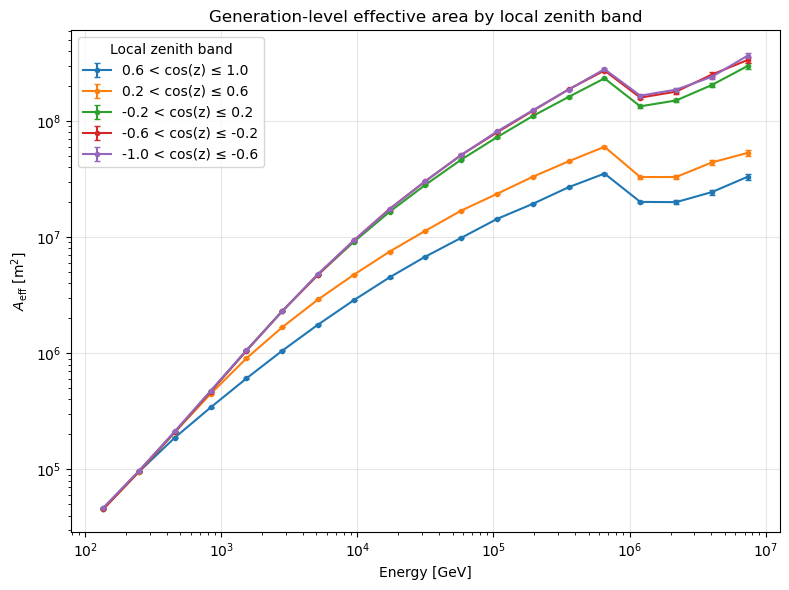

In [17]:
# Fewer energy bins make the banded plot more stable at high energy.
band_energy_bins = np.logspace(logE.min(), logE.max(), 20)
band_centers = log_bin_centers(band_energy_bins)
band_delta_E = np.diff(band_energy_bins)

cosz_bands = [
    (0.6, 1.0),
    (0.2, 0.6),
    (-0.2, 0.2),
    (-0.6, -0.2),
    (-1.0, -0.6),
]

plt.figure(figsize=(8, 6))

for band_min, band_max in cosz_bands:
    if band_max == 1.0:
        mask = (cosz >= band_min) & (cosz <= band_max)
    else:
        mask = (cosz >= band_min) & (cosz < band_max)

    sum_w_band, _ = np.histogram(E[mask], bins=band_energy_bins, weights=W[mask])
    sum_w2_band, _ = np.histogram(E[mask], bins=band_energy_bins, weights=W[mask]**2)
    counts_band, _ = np.histogram(E[mask], bins=band_energy_bins)

    delta_omega_band = 2 * np.pi * (band_max - band_min)
    A_eff_band_cm2 = sum_w_band / (band_delta_E * delta_omega_band)
    A_eff_band_unc_cm2 = np.sqrt(sum_w2_band) / (band_delta_E * delta_omega_band)

    A_eff_band_m2 = A_eff_band_cm2 / 1e4
    A_eff_band_unc_m2 = A_eff_band_unc_cm2 / 1e4

    nonzero = (sum_w_band > 0) & (counts_band > 0)
    y = A_eff_band_m2[nonzero]
    yerr = A_eff_band_unc_m2[nonzero]

    plt.errorbar(
        band_centers[nonzero],
        y,
        yerr=yerr,
        marker="o",
        markersize=3,
        linewidth=1.5,
        capsize=2,
        label=f"{band_min:.1f} < cos(z) ≤ {band_max:.1f}",
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel(r"$A_{\rm eff}$ [m$^2$]")
plt.title("Generation-level effective area by local zenith band")
plt.legend(title="Local zenith band")
plt.tight_layout()
plt.show()


**Interpretation.** Differences between local zenith bands are expected because column depth and geometry change with direction. Large error bars or isolated spikes mean the band is statistics limited. These curves should be described as local-zenith generation-level effective areas, not declination effective areas.


## 18. MC statistics by local zenith band

**Expectation.** The highest-energy bins may have very few generated events, especially after splitting into several angular bands. Noisy effective-area behavior in those bins should be interpreted as limited Monte Carlo statistics.


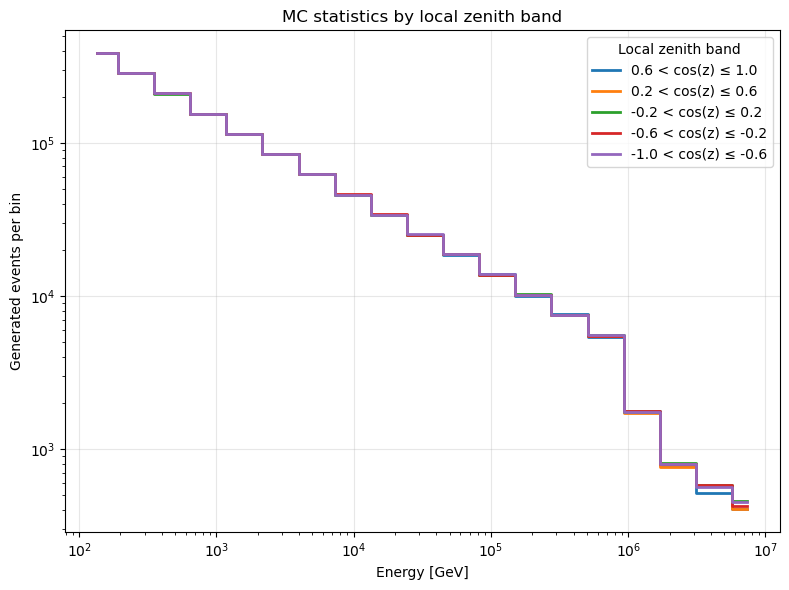

In [18]:
plt.figure(figsize=(8, 6))

for band_min, band_max in cosz_bands:
    if band_max == 1.0:
        mask = (cosz >= band_min) & (cosz <= band_max)
    else:
        mask = (cosz >= band_min) & (cosz < band_max)

    counts_band, _ = np.histogram(E[mask], bins=band_energy_bins)
    nonzero = counts_band > 0

    plt.step(
        band_centers[nonzero],
        counts_band[nonzero],
        where="mid",
        linewidth=2,
        label=f"{band_min:.1f} < cos(z) ≤ {band_max:.1f}",
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel("Generated events per bin")
plt.title("MC statistics by local zenith band")
plt.legend(title="Local zenith band")
plt.tight_layout()
plt.show()

**Interpretation.** This plot should be used together with the banded effective-area plot. If a high-energy bin has very few generated events, any sharp rise or drop in effective area is likely dominated by MC statistics rather than a robust detector response feature.


## 19. Summary of what each plot checks

- **LIW vs energy**: checks the energy scaling of `oneweight`. It is not expected to be only `E^+1.5` because LIW includes interaction and cross-section effects.
- **Unweighted `cos(zenith)`**: checks whether generated directions are uniform in solid angle.
- **Generated `dN/dE`**: checks whether the generated power law matches the configured `PowerLawIndex`.
- **Column depth vs zenith**: checks whether direction-dependent Earth and medium effects enter the weighting.
- **Column-depth lower envelope**: checks whether the sharp minimum is a physical or geometrical boundary rather than a repeated fill value.
- **LIW-weighted zenith**: shows the flat-flux LIW interaction contribution by local zenith. It is not the incoming neutrino flux at P-ONE.
- **Astrophysical shape weighting**: multiplies LIW by a chosen external flux shape such as `E^-3`.
- **Generation-level effective area**: uses LIW without applying any astrophysical flux. The uncertainty band is based on `sqrt(sum(w_i^2))` in each bin.
- **Detector-level effective area**: would require applying PMT response, trigger, reconstruction, and analysis selections before summing weights.
